# Mid Semester Project - DEEP Reinforcements Learning
Dear students,<br> this is the template notebook. Please copy it by clicking on the "File" tab and then on "Save a copy into drive".

---
<br>

### Name and ID:
Student 1: Omri Shimoni (OMRI WHAT IS UR ID?)
<br>
Student 2: Tom Bar 302278601
<br><br>
<img src="https://raw.githubusercontent.com/Farama-Foundation/Minigrid/master/minigrid-text.png">

### https://minigrid.farama.org/

# Pre-Requisit

## Installs

In [4]:
# %%capture
# !sudo apt-get update
# !sudo apt-get install -y xvfb ffmpeg freeglut3-dev
# !pip install 'imageio==2.4.0'
# !apt-get install python-opengl -y
# !apt install xvfb -y
# !pip install pyvirtualdisplay
# !pip install piglet
# !pip install gymnasium
# !apt-get install python-opengl -y
# !apt install xvfb -y
# !pip install -U --no-cache-dir gdown --pre
# !pip install minigrid

## Imports

In [3]:
from pyvirtualdisplay import Display
from IPython.display import HTML
from IPython import display as ipythondisplay
import pyvirtualdisplay
import IPython
import base64
import gymnasium
import minigrid
from minigrid.wrappers import RGBImgObsWrapper, RGBImgPartialObsWrapper, ImgObsWrapper, FullyObsWrapper, RGBImgPartialObsWrapper
import matplotlib.pyplot as plt
import imageio
import numpy as np
import cv2
import gymnasium

In [4]:
# Constants for the environemnt configuration do no change the values
highlight = False
render_mode = "rgb_array"

## Display utils
The cell below contains the video display configuration. No need to make changes here.

In [6]:
def embed_mp4(filename):
  """Embeds an mp4 file in the notebook."""
  video = open(filename,'rb').read()
  b64 = base64.b64encode(video)
  tag = '''
  <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
  Your browser does not support the video tag.
  </video>'''.format(b64.decode())

  return IPython.display.HTML(tag)
try:
    import sys
    if sys.platform.startswith("linux"):
        display = pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()
except (ImportError, FileNotFoundError):
    display = None

# Introduction

For this project, you will work with environments from the [MiniGrid](https://minigrid.farama.org) framework. MiniGrid is designed to test and benchmark reinforcement learning algorithms, offering a diverse range of tasks with varying levels of complexity.

MiniGrid environments are built around the concept of a partially observable, grid-based world where an agent operates to achieve predefined objectives.

## **MultiRoom Environment**

You will work with the **Dynamic Obstacles** see docomentation [here](https://minigrid.farama.org/environments/minigrid/DynamicObstaclesEnv/). Dynamic Obstacles introduces a level of complexity beyond simple navigation tasks by requiring the agent to navigate around moving obstacles while reaching a goal. This environment features obstacles that change position or direction over time, creating a dynamic challenge that tests the agent's ability to adapt and make real-time decisions. It serves as an excellent testbed for reinforcement learning algorithms that require temporal reasoning, prediction, and reactive planning in non-stationary environments.



## Understanding the `done` and `truncated` Mechanisms in `DynamicObstacles`

As you experienced in the MidTerm assignment, the **GYM** API returns multiple outputs from the **`step`** method. In the `DynamicObstacles` environment, two key mechanisms, **`done`** and **`truncated`**, are used to signify the end of an episode. These mechanisms are essential for managing the flow of training and providing valuable feedback about the agent's performance.


### `done`
- The `done` flag is set to `True` when the agent successfully reaches the goal.
- It indicates the successful termination of the episode, meaning the agent has completed the task.
- Example scenario: The agent navigates through all the rooms and reaches the green goal square in the final room.

### `truncated`
- The `truncated` flag is used to terminate an episode when a predefined condition is met, such as exceeding the maximum number of steps allowed.
- It does not necessarily indicate success or failure, but rather ensures that episodes do not run indefinitely.
- Example scenario: The agent fails to reach the goal within the allowed number of steps, and the episode ends prematurely.

**Pay Attention!**

Each time the environment is reset, the configuration of the rooms is randomized. This variability should be carefully considered during training, as resetting the environment every time the `max_step` limit is reached can make it challenging for the agent to learn effectively.

Additionally, note that the `max_step` parameter is defined as the number of rooms multiplied by 20.


## Random Action Rendering

In [9]:
env = gymnasium.make("MiniGrid-Dynamic-Obstacles-16x16-v0", render_mode=render_mode, highlight=highlight)
video_filename = './content/vid.mp4'
truncated = False
# Evaluation
with imageio.get_writer(video_filename, fps=16) as video:
  obs, _ = env.reset()
  done = False
  total_reward = 0
  step = 0
  while not truncated:
      action = env.action_space.sample()
      obs, reward, done, truncated  , _ = env.step(action)
      next_obs = obs  # Get agent's position directly from the environment
      video.append_data(env.render())
      step += 1
      if truncated:
        print("done","reward=", total_reward,"num_of_steps=",step)
        break
embed_mp4(video_filename)

done reward= 0 num_of_steps= 1024


## Wrappers for Observations: ImgObsWrapper and RGBImgPartialObsWrapper

For this project, you will use two wrappers provided by MiniGrid: **ImgObsWrapper** and **RGBImgPartialObsWrapper**. These wrappers modify the agent's observations.

### ImgObsWrapper
- The **ImgObsWrapper** converts the observation from its default dictionary format into a single image array.
- By default, observations in MiniGrid are returned as a dictionary containing both image data and other optional keys (e.g., mission strings). This wrapper extracts only the image component for simplicity.

### RGBImgPartialObsWrapper
- This wrapper provides a **partial view of the environment**, but instead of limiting it to a fixed field of view, it shows the **entire visible content of the current room** from the agent's position to the walls in the direction the agent is facing.
- The observation dynamically updates as the agent moves or turns, allowing it to see the layout of the room but not beyond its walls or through closed doors.
- This introduces the challenge of **partial observability across multiple rooms**, as the agent must explore and navigate to new rooms to gather more information about the environment.





### Wrapper Usage
To apply a wrapper, you can modify your environment setup as follows:

(56, 56, 3)


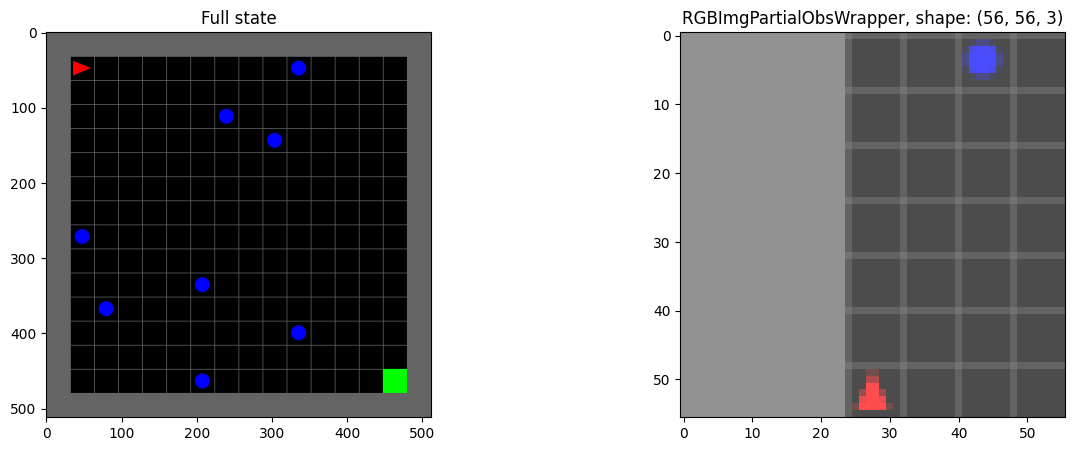

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
env = gymnasium.make("MiniGrid-Dynamic-Obstacles-16x16-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
obs, _ = env.reset()
print(obs.shape)
axs[1].imshow(obs)
axs[1].title.set_text(f'RGBImgPartialObsWrapper, shape: {obs.shape}')
axs[0].imshow(env.render())
axs[0].title.set_text(f'Full state')
plt.show()

## Initializing the smaller environments

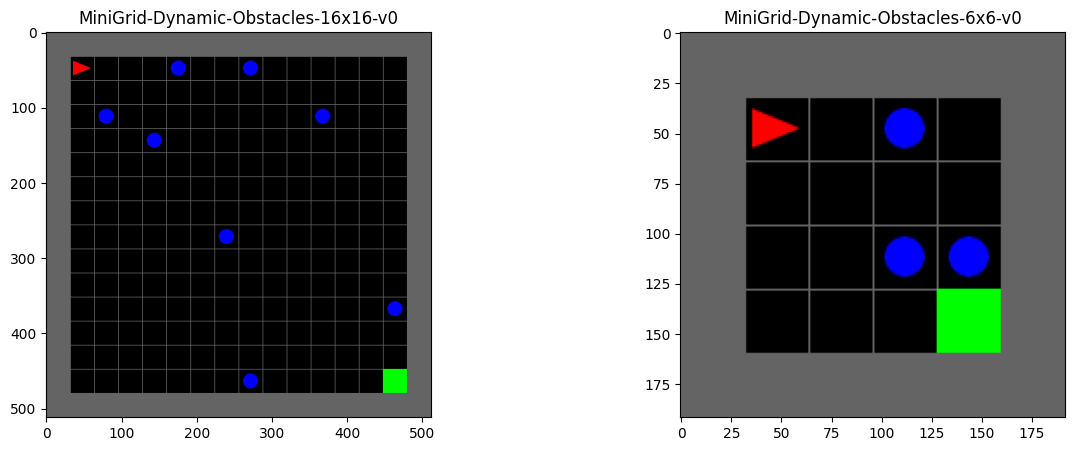

In [11]:
env = gymnasium.make("MiniGrid-Dynamic-Obstacles-16x16-v0", render_mode=render_mode, highlight=highlight)
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
obs, _ = env.reset()
axs[0].imshow(env.render())
axs[0].title.set_text(f'MiniGrid-Dynamic-Obstacles-16x16-v0')



env = gymnasium.make("MiniGrid-Dynamic-Obstacles-6x6-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
obs, _ = env.reset()
axs[1].imshow(env.render())
axs[1].title.set_text(f'MiniGrid-Dynamic-Obstacles-6x6-v0')
plt.show()

### Partial Observation Example

In [13]:
env = gymnasium.make("MiniGrid-Dynamic-Obstacles-16x16-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
video_filename = './content/vid_partial.mp4'
truncated = False
# Evaluation
with imageio.get_writer(video_filename, fps=10) as video:
  obs, _ = env.reset()
  done = False
  total_reward = 0
  step = 0
  while not done:
      action = env.action_space.sample()
      obs, reward, done, truncated  , _ = env.step(action)
      next_obs = obs  # Get agent's position directly from the environment
      video.append_data(obs)
      step += 1
      if truncated:
        print("done","reward=", total_reward,"num_of_steps=",step)
        break
embed_mp4(video_filename)

## Exmple from our solution

# Your Code here ...

# Setup

In [26]:
import random
import collections
import itertools
import math
import os
import time
import torch
import gymnasium as gym
import numpy as np
from torch import nn, optim
from minigrid.wrappers import FlatObsWrapper

device_name = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print("device_name", device_name)
device = torch.device(device_name)

MINIGRID_ENV = "MiniGrid-Dynamic-Obstacles-5x5-v0"
# MINIGRID_ENV = "MiniGrid-Dynamic-Obstacles-8x8-v0"
# MINIGRID_ENV = "MiniGrid-Dynamic-Obstacles-16x16-v0"
RENDER_MODE = "rgb_array"
HIGHLIGHT = False

def get_display():
    try:
        import sys
        if sys.platform.startswith("linux"):
            return pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()
    except (ImportError, FileNotFoundError):
        return None

def make_env(seed=None):
    env = gymnasium.make(MINIGRID_ENV, render_mode=RENDER_MODE, highlight=HIGHLIGHT)
    env = RGBImgPartialObsWrapper(env)
    env = ImgObsWrapper(env)
    env.reset(seed=seed)
    return env

device_name mps


# Replay Buffer

In [16]:
Transition = collections.namedtuple("Transition", "s a r s1 done")
class Replay:
    def __init__(self, cap=50_000):
        self.mem, self.cap = collections.deque(maxlen=cap), cap
    def put(self,*args): self.mem.append(Transition(*[torch.as_tensor(x) for x in args]))
    def sample(self, k): return random.sample(self.mem, k)
    def __len__(self): return len(self.mem)

def epsilon_by_step(step, eps_start=1.0, eps_end=0.05, eps_decay=25_000):
    return eps_end + (eps_start - eps_end) * math.exp(-step/eps_decay)

# Agent

In [17]:
class ConvNet(nn.Module):
    def __init__(self, in_shape, n_actions):
        super().__init__()
        c, h, w = in_shape  # we'll convert obs to C×H×W
        self.feature = nn.Sequential(
            nn.Conv2d(c, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
        )
        # compute flattened conv output size
        with torch.no_grad():
            n = self.feature(torch.zeros(1, c, h, w)).view(1, -1).size(1)

        self.head = nn.Sequential(
            nn.Linear(n, 512), nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, obs):
      # obs arrives H×W×C; convert to C×H×W
      if obs.ndim == 3:
          obs = obs.permute(2, 0, 1).unsqueeze(0)
      else:
          obs = obs.permute(0, 3, 1, 2)

      obs = obs.float() / 255.0
      x   = self.feature(obs)
      x   = torch.flatten(x, 1)          # <-- robust flatten
      return self.head(x)

class Agent:
    """
    DQN agent for image observations.
    Pass `in_shape = (C, H, W)`, not a flat size.
    """
    def __init__(self, in_shape, n_actions,
                 gamma=0.99, lr=1e-3, tau=0.01):
        self.q      = ConvNet(in_shape, n_actions).to(device)
        self.q_tgt  = ConvNet(in_shape, n_actions).to(device)
        self.q_tgt.load_state_dict(self.q.state_dict())

        self.opt   = optim.Adam(self.q.parameters(), lr)
        self.gamma = gamma
        self.tau   = tau
        self.n_actions = n_actions

    # ε‑greedy action
    @torch.no_grad()
    def act(self, obs, eps):
        if random.random() < eps:
            return random.randrange(self.n_actions)
        return int(self.q(obs.unsqueeze(0).to(device)).argmax().cpu())

    # one gradient step on a minibatch
    def update(self, batch):
        s, a, r, s1, done = map(torch.stack, zip(*batch))
        s, s1 = s.to(device), s1.to(device)
        a = a.to(device).long().unsqueeze(1)
        r, done = r.to(device).float(), done.to(device).float()

        q_sa = self.q(s).gather(1, a).squeeze()
        with torch.no_grad():
            tgt_max = self.q_tgt(s1).max(1).values
            q_target = r + self.gamma * tgt_max * (1 - done)

        loss = nn.functional.smooth_l1_loss(q_sa, q_target)
        self.opt.zero_grad(); loss.backward(); self.opt.step()

        # soft‑update target network
        for tgt, src in zip(self.q_tgt.parameters(), self.q.parameters()):
            tgt.data.mul_(1 - self.tau).add_(self.tau * src.data)

# Training

In [20]:
SEED = None  # can be changed to fixed integer
env = make_env(seed=SEED);
obs_shape = env.observation_space.shape
c, h, w = obs_shape[2], obs_shape[0], obs_shape[1]
agent = Agent((c, h, w), env.action_space.n)

BATCH = 64; WARMUP = 1_000; MAX_STEPS = 100_000
reward_log, ep_reward, ep_len, obs, _ = [], 0.0, 0, *env.reset()
buf = Replay()
for step in range(1, MAX_STEPS+1):
    eps = epsilon_by_step(step)
    action = agent.act(torch.tensor(obs), eps)
    next_obs, reward, term, trunc, _ = env.step(action)
    done = term or trunc
    buf.put(obs, action, reward, next_obs, float(done))
    obs, ep_reward, ep_len = next_obs, ep_reward+reward, ep_len+1
    if done:
        reward_log.append(ep_reward); obs, _ = env.reset(); ep_reward, ep_len = 0.0,0
        # simple monitor
        if len(reward_log)%20==0:
            avg = np.mean(reward_log[-20:]); print(f"step={step:>6d}  avgR(20)={avg:6.2f}")
            if avg > 0.9: break                        # solved (max reward≈1.0)
    # learning
    if len(buf) >= WARMUP and step % 4 == 0:
        agent.update(buf.sample(BATCH))

step=   152  avgR(20)= -0.91
step=   258  avgR(20)= -1.00
step=   359  avgR(20)= -1.00
step=   475  avgR(20)= -1.00
step=   591  avgR(20)= -1.00
step=   689  avgR(20)= -0.91
step=   818  avgR(20)= -1.00
step=   912  avgR(20)= -1.00
step=  1033  avgR(20)= -1.00
step=  1132  avgR(20)= -1.00
step=  1230  avgR(20)= -1.00
step=  1378  avgR(20)= -1.00
step=  1478  avgR(20)= -1.00
step=  1547  avgR(20)= -1.00
step=  1662  avgR(20)= -1.00
step=  1799  avgR(20)= -1.00
step=  1941  avgR(20)= -1.00
step=  2026  avgR(20)= -1.00
step=  2122  avgR(20)= -1.00
step=  2265  avgR(20)= -1.00
step=  2396  avgR(20)= -1.00
step=  2501  avgR(20)= -1.00
step=  2604  avgR(20)= -1.00
step=  2715  avgR(20)= -1.00
step=  2837  avgR(20)= -1.00
step=  2958  avgR(20)= -1.00
step=  3060  avgR(20)= -1.00
step=  3178  avgR(20)= -0.91
step=  3349  avgR(20)= -1.00
step=  3428  avgR(20)= -1.00
step=  3578  avgR(20)= -1.00
step=  3677  avgR(20)= -1.00
step=  3832  avgR(20)= -1.00
step=  3928  avgR(20)= -1.00
step=  4041  a

# Training Plot

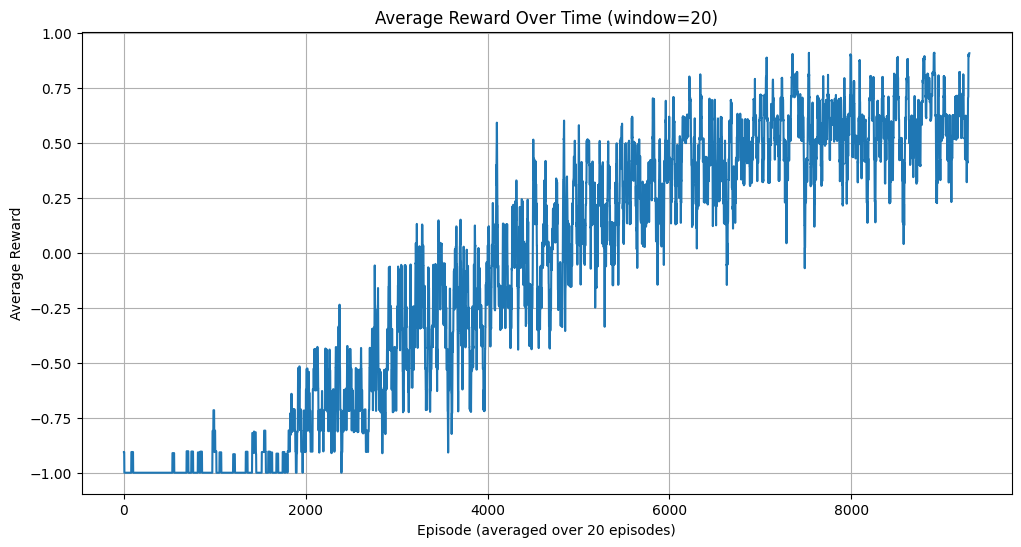

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the moving average of the reward log
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size), 'valid') / window_size

avg_reward = moving_average(reward_log, 20)

# Plotting the smoothed reward
plt.figure(figsize=(12, 6))
plt.plot(avg_reward)
plt.title("Average Reward Over Time (window=20)")
plt.xlabel("Episode (averaged over 20 episodes)")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

# Evaluation

In [22]:
def evaluate(n_episodes=30):
    env = make_env(); scores=[]
    for _ in range(n_episodes):
        obs,_ = env.reset(); done=False; score=0
        while not done:
            action = agent.act(torch.tensor(obs), 0.0)
            obs, reward, term, trunc, _ = env.step(action)
            done=term or trunc; score += reward
        scores.append(score)
    return np.mean(scores)

print("Mean reward over 30 eval episodes:", evaluate())

Mean reward over 30 eval episodes: 0.9022


# Demo Episode

In [29]:
from minigrid.wrappers import FlatObsWrapper

# start head-less display for Gym render
display = get_display()

# 1️⃣  make a visual env (training env stays head-less)
# vis_env = FlatObsWrapper(gym.make(MINIGRID_ENV, render_mode="rgb_array"))
vis_env = make_env()

# 2️⃣  collect frames with the trained agent
frames, obs = [], vis_env.reset(seed=123)[0]
done = False
while not done:
    frames.append(vis_env.render())
    action = agent.act(torch.tensor(obs), 0.0)
    obs, _, term, trunc, _ = vis_env.step(action)
    done = term or trunc
frames.append(vis_env.render())
vis_env.close()

# 3️⃣  write to MP4
vid_path = "./content/minigrid_rollout.mp4"
with imageio.get_writer(vid_path, fps=8, codec="libx264") as w:
    for f in frames:
        w.append_data(f)

# 4️⃣  embed video inline
embed_mp4(vid_path)